# GHRSST MUR JPL L4 SST Analysis — Reproducible Notebook

**Product:** MUR-JPL-L4-GLOB-v4.1 (Multi-scale Ultra-high Resolution SST)
**Resolution:** 0.01° global grid (~36,000 × 18,000 pixels per file)
**Frequency:** Daily NetCDF files

This notebook produces:
1. **Monthly mean maps** — 3×4 panel of monthly mean SST for each year in `YEARS`
2. **Daily maps** — panel of daily SST maps for a chosen month and day range

---

### How to use it Guide

1. **Edit only the Configuration cell** (Section 2) — set paths, years, region, and plot options
2. Run → **Restart & Run All**
3. Output PNGs are saved to `OUTPUT_DIR`

> **Requirements:** `xarray`, `numpy`, `matplotlib`, `cartopy`

---
## Section 1 — Imports

In [2]:
import os
import re
import glob
import warnings
from datetime import datetime
from math import ceil
from calendar import month_name

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Libraries loaded.")

Libraries loaded.


---
## Section 2 — Configuration

> **Edit ONLY this cell.** All paths, years, region, and plot settings live here.
> After editing, run **Restart & Run All** to regenerate all outputs.

In [9]:
# =============================================================================
# CONFIGURATION — Edit ONLY this cell
# =============================================================================

# ---- Paths ----------------------------------------------------------------
# Folder containing the daily *.nc files downloaded from PO.DAAC
DATA_DIR  = r"C:\Users\abhik\Downloads\New_folder\MUR-JPL-L4-GLOB-v4.1_4.1-20260316_132446"

# Folder where output PNGs are saved (created automatically if absent)
OUTPUT_DIR = r"C:\Users\abhik\Downloads\New_folder\sst_plotssss"

# ---- Years ----------------------------------------------------------------
# List of integer years to process. The notebook loops over each year and
# produces one output file per plot type per year.
# Example for multiple years:  YEARS = [2022, 2023, 2024]
YEARS = [2024]

# ---- Region of interest ---------------------------------------------------
# [lon_min, lon_max, lat_min, lat_max] in decimal degrees.
# Positive = East / North,  Negative = West / South.
# Set to None to plot the full global domain.
#
# Common presets:
#   Indian Ocean  : [40, 100, -10,  30]
#   Bay of Bengal : [80, 100,   5,  25]
#   Arabian Sea   : [55,  78,   5,  25]
#   Global        : None
REGION = [80, 100, 5, 25]

# ---- Plot selection -------------------------------------------------------
DO_MONTHLY = True   # 3×4 panel of monthly mean SST  (one figure per year)
DO_DAILY   = True   # Panel of daily SST for a chosen month (one figure per year)

# ---- Daily plot settings (only used when DO_DAILY = True) -----------------
DAILY_MONTH     = 10   # Month to plot  (1 = January … 12 = December)
DAILY_DAY_START = 11    # First day of the range (inclusive)
DAILY_DAY_END   = 15   # Last day  of the range (inclusive)
DAYS_PER_ROW    = 5    # Number of subplot columns in the daily panel

# ---- Colormap & rendering -------------------------------------------------
# Tip: Run the SST Statistics cell (Section 5) first to find the best
# SST_VMIN / SST_VMAX for your region, then update these values.
SST_CMAP   = "RdYlBu_r"   # red = warm, blue = cold (any matplotlib colormap)
SST_VMIN   = -2.0          # Lower colorbar limit (°C)
SST_VMAX   = 32.0          # Upper colorbar limit (°C)
DOWNSAMPLE = 5             # Pixel stride: 1 = full res, 5 = fast, 10 = very fast

# ---- Derived (do not edit) ------------------------------------------------
if REGION is not None:
    REGION_LABEL = f"[{REGION[0]}°–{REGION[1]}°E, {REGION[2]}°–{REGION[3]}°N]"
else:
    REGION_LABEL = "Global"

print("Configuration loaded.")
print(f"  Data dir    : {DATA_DIR}")
print(f"  Output dir  : {OUTPUT_DIR}")
print(f"  Years       : {YEARS}")
print(f"  Region      : {REGION_LABEL}")
print(f"  Monthly     : {DO_MONTHLY}")
print(f"  Daily       : {DO_DAILY}")
if DO_DAILY:
    print(f"  Daily month : {month_name[DAILY_MONTH]}  "
          f"days {DAILY_DAY_START}–{DAILY_DAY_END}")
print(f"  SST range   : {SST_VMIN}°C – {SST_VMAX}°C  |  downsample={DOWNSAMPLE}")

Configuration loaded.
  Data dir    : C:\Users\abhik\Downloads\New_folder\MUR-JPL-L4-GLOB-v4.1_4.1-20260316_132446
  Output dir  : C:\Users\abhik\Downloads\New_folder\sst_plotssss
  Years       : [2024]
  Region      : [80°–100°E, 5°–25°N]
  Monthly     : True
  Daily       : True
  Daily month : October  days 11–15
  SST range   : -2.0°C – 32.0°C  |  downsample=5


---
## Section 3 — Helper Functions

Run this section once to register all helper functions.
Each function is fully documented — hover over a call in VS Code or JupyterLab for the complete docstring.

In [10]:
def extract_date_from_filename(filepath):
    """
    Parse a Python ``datetime`` from the first 8 characters of a MUR filename.

    MUR filenames follow the naming convention::

        YYYYMMDDHHMMSS-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc

    This function extracts the leading ``YYYYMMDD`` date token and converts
    it to a ``datetime`` object.  The result is used downstream to sort files
    chronologically and to filter by year, month, or day.

    Parameters
    ----------
    filepath : str
        Absolute or relative path to a MUR NetCDF file.  Only the basename
        is inspected; the directory portion is ignored.

    Returns
    -------
    datetime.datetime
        Midnight on the file date (hour, minute, second all zero).

    Raises
    ------
    ValueError
        If the filename does not begin with an 8-digit date string.

    Examples
    --------
    >>> extract_date_from_filename("20240601090000-JPL-L4_GHRSST.nc")
    datetime.datetime(2024, 6, 1, 0, 0)
    """
    filename = os.path.basename(filepath)
    match = re.match(r'^(\d{8})', filename)
    if match:
        return datetime.strptime(match.group(1), '%Y%m%d')
    raise ValueError(f"Cannot parse date from filename: {filename}")

In [11]:
def scan_dataset(data_dir):
    """
    Discover all NetCDF files in *data_dir* and report which years are present.

    Performs a non-recursive glob for ``*.nc`` files directly inside
    *data_dir*, then parses the calendar year from each filename.  Files
    whose names do not match the expected date prefix are silently skipped
    (they still appear in *all_files* but do not contribute to *years*).

    Parameters
    ----------
    data_dir : str
        Path to the directory that holds the daily MUR NetCDF files.

    Returns
    -------
    all_files : list of str
        Chronologically sorted list of absolute paths to every ``*.nc``
        file found inside *data_dir*.
    years : set of int
        Set of calendar years inferred from the filenames.  Use
        ``sorted(years)`` for an ordered list.

    Examples
    --------
    >>> files, years = scan_dataset(r"C:\\data\\MUR-2024")
    >>> print(sorted(years))
    [2024]
    >>> print(len(files))
    366
    """
    pattern = os.path.join(data_dir, "*.nc")
    all_files = sorted(glob.glob(pattern))

    years = set()
    for f in all_files:
        try:
            years.add(extract_date_from_filename(f).year)
        except ValueError:
            pass

    return all_files, years

In [12]:
def load_sst(filepath, region=None, downsample=1):
    """
    Load the ``analysed_sst`` field from a MUR NetCDF file and return it in °C.

    Execution steps
    ---------------
    1. **Open** the file with ``xr.open_dataset`` (lazy / memory-mapped).
    2. **Squeeze** the singleton ``time`` dimension so the result is 2-D (lat × lon).
    3. **Subset** to *region* with label-based indexing (``DataArray.sel``).
       Skipped when *region* is ``None`` — the full global domain is used.
    4. **Convert** from Kelvin to Celsius by subtracting 273.15.
    5. **Downsample** — keep every *downsample*-th pixel along both spatial
       axes.  Reduces resolution but lowers memory use and speeds plotting.
    6. **Close** the file handle to free OS resources.

    Parameters
    ----------
    filepath : str
        Path to a single MUR daily NetCDF file.
    region : list of float or None, optional
        ``[lon_min, lon_max, lat_min, lat_max]`` bounding box in decimal
        degrees.  ``None`` loads the full global domain.
    downsample : int, optional
        Spatial pixel stride.  ``1`` = native 0.01° resolution;
        ``5`` ≈ 0.05°; ``10`` ≈ 0.1°.  Default is ``1``.

    Returns
    -------
    xr.DataArray
        2-D (lat × lon) SST array in degrees Celsius.  Retains ``lat`` and
        ``lon`` coordinate arrays so the result can be passed directly to
        ``make_sst_map`` without further coordinate handling.

    Raises
    ------
    KeyError
        If ``analysed_sst`` is not a variable in the file (wrong product or
        corrupt file).

    Examples
    --------
    >>> sst = load_sst("20240601090000-JPL.nc", region=[80, 100, 5, 25], downsample=5)
    >>> print(f"{float(sst.min()):.1f}°C  to  {float(sst.max()):.1f}°C")
    27.3°C  to  31.8°C
    """
    ds = xr.open_dataset(filepath)
    sst = ds['analysed_sst'].squeeze('time')

    if region is not None:
        lon_min, lon_max, lat_min, lat_max = region
        sst = sst.sel(lon=slice(lon_min, lon_max),
                      lat=slice(lat_min, lat_max))

    sst = sst - 273.15  # Kelvin → Celsius

    if downsample > 1:
        sst = sst[::downsample, ::downsample]

    ds.close()
    return sst

In [13]:
def make_sst_map(ax, sst_data, title, vmin, vmax, cmap, show_cbar=False):
    """
    Render a filled SST map on a Cartopy ``PlateCarree`` axes object.

    Draws the SST field with ``pcolormesh`` and overlays standard map features:
    land mask (light grey), coastlines (0.5 pt solid), country borders (0.3 pt
    dashed), and degree gridlines with axis labels on the left and bottom
    edges only.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        A Matplotlib axes created with ``projection=ccrs.PlateCarree()``.
        The geographic extent is **not** set inside this function — the caller
        controls the zoom level (call ``ax.set_extent(region)`` afterwards).
    sst_data : xr.DataArray
        2-D SST array in °C with ``lat`` and ``lon`` as named coordinates.
        Typically the output of ``load_sst``.
    title : str
        Text placed above the subplot (e.g. a month name or date string).
    vmin : float
        Lower colorbar limit in °C.  Pixels colder than *vmin* are
        saturated at the bottom colour of *cmap*.
    vmax : float
        Upper colorbar limit in °C.  Pixels warmer than *vmax* are
        saturated at the top colour of *cmap*.
    cmap : str
        Matplotlib colormap name (e.g. ``"RdYlBu_r"`` for diverging
        blue-cold / red-warm palette).
    show_cbar : bool, optional
        If ``True``, a small horizontal colorbar is drawn directly below *ax*.
        Keep ``False`` (default) when a single shared colorbar will be added
        by the caller across multiple panels.

    Returns
    -------
    matplotlib.collections.QuadMesh
        The handle returned by ``pcolormesh``.  Pass this to
        ``fig.colorbar(handle, ...)`` to create a shared colorbar.

    Notes
    -----
    Gridline labels are suppressed on the top and right edges to prevent
    overlap in tight multi-panel grid layouts.
    """
    lon = sst_data.coords['lon'].values
    lat = sst_data.coords['lat'].values

    ax.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5,          zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle='--', zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray',
                      alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

    img = ax.pcolormesh(lon, lat, sst_data.values,
                        transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax,
                        shading='auto', zorder=0)

    ax.set_title(title, fontsize=10, fontweight='bold')

    if show_cbar:
        plt.colorbar(img, ax=ax, orientation='horizontal',
                     label='SST (°C)', pad=0.05, shrink=0.8)

    return img

In [14]:
def get_files_for_month(all_files, year, month):
    """
    Build a day-to-filepath mapping for all files in a given year and month.

    Iterates over *all_files*, calls ``extract_date_from_filename`` on each,
    and collects those whose year and month match the requested values.
    Files that cannot be parsed are silently skipped.

    Parameters
    ----------
    all_files : list of str
        Sorted list of all NetCDF file paths, as returned by ``scan_dataset``.
    year : int
        Four-digit calendar year (e.g. ``2024``).
    month : int
        Month number in the range 1–12.

    Returns
    -------
    dict
        ``{day_number (int): filepath (str)}`` for every file in *all_files*
        that falls within the requested year and month.  The dictionary is
        unordered — iterate over ``sorted(result.items())`` for chronological
        order.

    Examples
    --------
    >>> june_files = get_files_for_month(all_files, 2024, 6)
    >>> print(sorted(june_files.keys()))
    [1, 2, 3, ..., 30]
    """
    month_files = {}
    for filepath in all_files:
        try:
            d = extract_date_from_filename(filepath)
            if d.year == year and d.month == month:
                month_files[d.day] = filepath
        except ValueError:
            continue
    return month_files


print("All helper functions defined successfully.")

All helper functions defined successfully.


---
## Section 4 — Dataset Exploration

Scan `DATA_DIR`, report file count, date range, files per month, and the
NetCDF structure of one sample file.  No output files are created here.

In [15]:
# Scan the data directory
print("Scanning dataset …")
all_files, available_years = scan_dataset(DATA_DIR)

print(f"\n  Total .nc files : {len(all_files)}")
print(f"  Years found     : {', '.join(str(y) for y in sorted(available_years))}")

if not all_files:
    raise FileNotFoundError(
        f"No .nc files found in:\n  {DATA_DIR}\n\n"
        "Check that DATA_DIR in the Configuration cell points to the correct folder."
    )

# Date range and files-per-month breakdown
dates = []
for f in all_files:
    try:
        dates.append(extract_date_from_filename(f))
    except ValueError:
        pass

if dates:
    d_sorted = sorted(dates)
    print(f"  Date range      : {d_sorted[0]:%Y-%m-%d}  →  {d_sorted[-1]:%Y-%m-%d}")
    print("\n  Files per month:")
    for y, m in sorted(set((d.year, d.month) for d in dates)):
        count = sum(1 for d in dates if d.year == y and d.month == m)
        print(f"    {y}-{m:02d}  :  {count:3d} files")

# Structure of one sample file
print(f"\n  Sample file : {os.path.basename(all_files[0])}")
ds = xr.open_dataset(all_files[0])
print(f"  Dimensions  : {dict(ds.dims)}")
print("\n  Variables:")
for var in ds.data_vars:
    v = ds[var]
    print(f"    {var:25s}  shape={v.shape}  units={v.attrs.get('units', '?')}")
ds.close()

Scanning dataset …

  Total .nc files : 367
  Years found     : 2024, 2025
  Date range      : 2024-01-01  →  2025-01-01

  Files per month:
    2024-01  :   31 files
    2024-02  :   29 files
    2024-03  :   31 files
    2024-04  :   30 files
    2024-05  :   31 files
    2024-06  :   30 files
    2024-07  :   31 files
    2024-08  :   31 files
    2024-09  :   30 files
    2024-10  :   31 files
    2024-11  :   30 files
    2024-12  :   31 files
    2025-01  :    1 files

  Sample file : 20240101090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc
  Dimensions  : {'time': 1, 'lat': 17999, 'lon': 36000}

  Variables:
    analysed_sst               shape=(1, 17999, 36000)  units=kelvin
    analysis_error             shape=(1, 17999, 36000)  units=kelvin
    mask                       shape=(1, 17999, 36000)  units=?
    sea_ice_fraction           shape=(1, 17999, 36000)  units=?
    dt_1km_data                shape=(1, 17999, 36000)  units=?
    sst_anomaly                shape=(1, 17

---
## Section 5 — SST Statistics *(optional)*

Samples one file per month to find the actual SST range inside your region.
The **recommended** `SST_VMIN` / `SST_VMAX` values printed at the end give
finer colour resolution than the global defaults (`-2` to `32 °C`).

> Update the values in the **Configuration cell** and run **Restart & Run All**.

In [ ]:
print(f"Computing SST statistics for region {REGION_LABEL} …")
print("(sampling the first file of each month — fast)\n")

# Collect the first file of every year-month present in the dataset
month_samples = {}
for f in all_files:
    try:
        d = extract_date_from_filename(f)
        key = (d.year, d.month)
        if key not in month_samples:
            month_samples[key] = f
    except ValueError:
        pass

all_ocean_values = []

print(f"{'Date':>12}  {'Min':>7}  {'Max':>7}  {'Mean':>7}  {'Std':>6}")
print("-" * 52)

for (yr, mo) in sorted(month_samples):
    filepath = month_samples[(yr, mo)]
    try:
        sst = load_sst(filepath, REGION, DOWNSAMPLE)
        vals = sst.values[~np.isnan(sst.values)]
        if len(vals) == 0:
            continue
        all_ocean_values.extend(vals.tolist())
        print(f"  {yr}-{mo:02d}-01  "
              f"{np.min(vals):6.2f}°  "
              f"{np.max(vals):6.2f}°  "
              f"{np.mean(vals):6.2f}°  "
              f"{np.std(vals):5.2f}°")
    except Exception as e:
        print(f"  {yr}-{mo:02d}-01  error: {e}")

if all_ocean_values:
    arr = np.array(all_ocean_values)
    p01, p99 = np.percentile(arr, [1, 99])
    print("\n" + "=" * 52)
    print("RECOMMENDED — update Configuration cell with:")
    print(f"  SST_VMIN = {np.floor(p01):.1f}   # 1st percentile")
    print(f"  SST_VMAX = {np.ceil(p99):.1f}  # 99th percentile")
    print("=" * 52)

---
## Section 6 — Monthly Mean Plots

Produces one 3×4 panel figure per year in `YEARS`.  Each panel shows the
monthly mean SST averaged from all daily files for that calendar month.

**Output filename:** `SST_Monthly_Mean_<YEAR>.png`

In [29]:
def create_monthly_mean_plots(all_files, year, output_dir, region, region_label,
                               vmin, vmax, cmap, downsample):
    """
    Build and save a 3×4 panel figure of monthly mean SST for one calendar year.

    For each of the 12 calendar months the function:

    1. Calls ``get_files_for_month`` to find all daily files for that month.
    2. Loads each daily file with ``load_sst`` (applies region subsetting and
       spatial downsampling as configured).
    3. Stacks the daily arrays along a new ``'day'`` dimension with
       ``xr.concat`` and computes the mean along that axis.
    4. Renders the monthly mean on a Cartopy ``PlateCarree`` subplot via
       ``make_sst_map``.

    After all 12 panels are drawn, a single shared horizontal colorbar is
    appended below the panel grid.  Months with no data files are rendered as
    blank subplots (``axis('off')``).

    Parameters
    ----------
    all_files : list of str
        Complete sorted file list returned by ``scan_dataset``.
    year : int
        Calendar year to process (e.g. ``2024``).
    output_dir : str
        Directory where the PNG is saved.  Created automatically if absent.
    region : list of float or None
        ``[lon_min, lon_max, lat_min, lat_max]`` or ``None`` for global.
    region_label : str
        Human-readable region string used in the figure super-title
        (e.g. ``"[80°–100°E, 5°–25°N]"``).
    vmin, vmax : float
        Colorbar limits in °C.
    cmap : str
        Matplotlib colormap name.
    downsample : int
        Spatial stride forwarded to ``load_sst``.

    Returns
    -------
    str or None
        Absolute path to the saved PNG, or ``None`` if nothing could be
        plotted (e.g. no files found for *year*).

    Notes
    -----
    Peak memory usage scales with
    ``n_days_in_month × n_lat_pixels × n_lon_pixels × 8 bytes``.
    Increase *downsample* if you encounter out-of-memory errors.
    """
    print(f"\n{'='*65}")
    print(f"Monthly mean maps — {year}")
    print("=" * 65)

    os.makedirs(output_dir, exist_ok=True)

    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    img_handle = None

    for month_idx in range(12):
        month_num = month_idx + 1
        ax = axes[month_idx]
        print(f"  {month_name[month_num]:>12} {year} … ", end="", flush=True)

        month_files = get_files_for_month(all_files, year, month_num)

        if not month_files:
            ax.set_title(f"{month_name[month_num]} (no data)", fontsize=10)
            ax.axis('off')
            print("no data")
            continue

        daily_sst_list = []
        for day, filepath in sorted(month_files.items()):
            try:
                daily_sst_list.append(load_sst(filepath, region, downsample))
            except Exception as e:
                print(f"\n    Warning — day {day}: {e}", end="")

        if not daily_sst_list:
            ax.set_title(f"{month_name[month_num]} (load error)", fontsize=10)
            ax.axis('off')
            print("load error")
            continue

        monthly_mean = xr.concat(daily_sst_list, dim='day').mean(dim='day')
        img_handle = make_sst_map(ax, monthly_mean, month_name[month_num],
                                   vmin, vmax, cmap)

        if region is not None:
            ax.set_extent(region, crs=ccrs.PlateCarree())

        print(f"done ({len(daily_sst_list)} days)")

    if img_handle is not None:
        cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.02])
        cbar = fig.colorbar(img_handle, cax=cbar_ax,
                            orientation='horizontal', extend='both')
        cbar.set_label('Sea Surface Temperature (°C)', fontsize=12)

    fig.suptitle(
        f"MUR GHRSST — Monthly Mean SST (°C) | {year}\n{region_label}",
        fontsize=14, fontweight='bold', y=0.98
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])

    out_path = os.path.join(output_dir, f"SST_Monthly_Mean_{year}.png")
    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')  
    fig.show()
    # plt.close(fig)
    print(f"\n  Saved → {out_path}")
    return out_path


Monthly mean maps — 2024
       January 2024 … done (31 days)
      February 2024 … done (29 days)
         March 2024 … done (31 days)
         April 2024 … done (30 days)
           May 2024 … done (31 days)
          June 2024 … done (30 days)
          July 2024 … done (31 days)
        August 2024 … done (31 days)
     September 2024 … done (30 days)
       October 2024 … done (31 days)
      November 2024 … done (30 days)
      December 2024 … done (31 days)

  Saved → C:\Users\abhik\Downloads\New_folder\sst_plotssss\SST_Monthly_Mean_2024.png


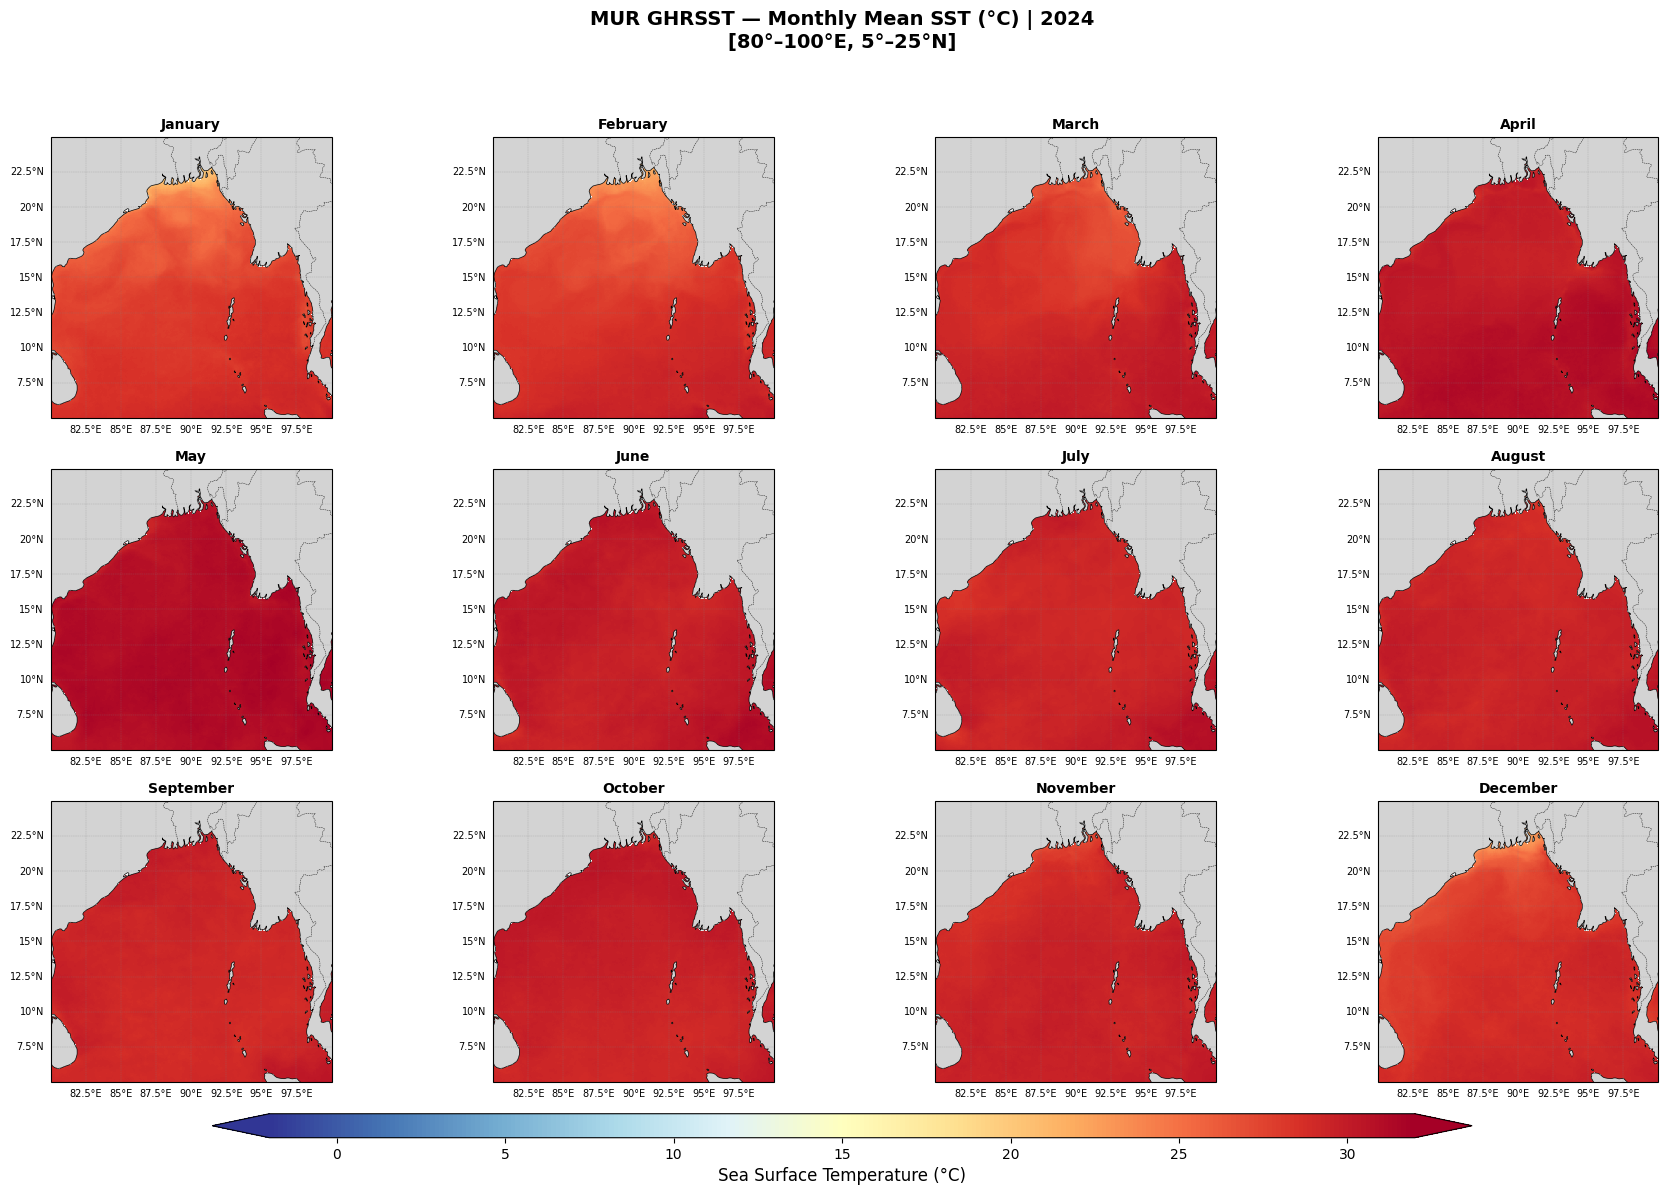

In [30]:
if DO_MONTHLY:
    monthly_outputs = []
    for yr in YEARS:
        path = create_monthly_mean_plots(
            all_files=all_files,
            year=yr,
            output_dir=OUTPUT_DIR,
            region=REGION,
            region_label=REGION_LABEL,
            vmin=SST_VMIN,
            vmax=SST_VMAX,
            cmap=SST_CMAP,
            downsample=DOWNSAMPLE,
        )
        if path:
            monthly_outputs.append(path)
else:
    print("DO_MONTHLY = False — skipping monthly mean plots.")
    monthly_outputs = []

---
## Section 7 — Daily Plots

Produces one panel figure per year in `YEARS`, showing daily SST maps for
the month and day range set in the Configuration cell.

**Output filename:** `SST_Daily_<YEAR>_<MM>_Day<start>-<end>.png`

In [27]:
def create_daily_plots(all_files, year, month, day_start, day_end, days_per_row,
                       output_dir, region, region_label, vmin, vmax, cmap, downsample):
    """
    Build and save a panel figure showing daily SST maps for a date range.

    Loads one SST field per requested calendar day and tiles the maps in a
    grid with *days_per_row* columns.  Days for which no file exists in the
    dataset (e.g. data gaps) are silently omitted from the panel.  Days that
    fail to load are rendered as blank subplots with an error label.

    Workflow per day
    ----------------
    1. Look up the daily filepath in the ``{day: path}`` dict returned by
       ``get_files_for_month``.
    2. Call ``load_sst`` to read, region-subset, and convert the SST field.
    3. Call ``make_sst_map`` to render the field on the corresponding subplot.
    4. Call ``ax.set_extent`` to zoom the panel to *region* (if given).

    A shared horizontal colorbar is drawn below the full panel grid after all
    days have been processed.  Unused subplot slots (when the number of plotted
    days is not a multiple of *days_per_row*) are hidden with ``axis('off')``.

    Parameters
    ----------
    all_files : list of str
        Complete sorted file list returned by ``scan_dataset``.
    year : int
        Calendar year (e.g. ``2024``).
    month : int
        Month number 1–12.
    day_start : int
        First day of the range to plot (inclusive).
    day_end : int
        Last day of the range to plot (inclusive).
    days_per_row : int
        Number of subplot columns.  More columns produce a wider figure.
    output_dir : str
        Directory where the PNG is saved.  Created automatically if absent.
    region : list of float or None
        ``[lon_min, lon_max, lat_min, lat_max]`` or ``None`` for global.
    region_label : str
        Human-readable region string used in the figure super-title.
    vmin, vmax : float
        Colorbar limits in °C.
    cmap : str
        Matplotlib colormap name.
    downsample : int
        Spatial stride forwarded to ``load_sst``.

    Returns
    -------
    str or None
        Absolute path to the saved PNG, or ``None`` if no data files were
        found for the requested month and day range.
    """
    print(f"\n{'='*65}")
    print(f"Daily maps — {month_name[month]} {year}, days {day_start}–{day_end}")
    print("=" * 65)

    os.makedirs(output_dir, exist_ok=True)

    month_files = get_files_for_month(all_files, year, month)
    days_to_plot = [
        (d, month_files[d])
        for d in range(day_start, day_end + 1)
        if d in month_files
    ]

    if not days_to_plot:
        print(f"  No data files for {month_name[month]} {year} "
              f"days {day_start}–{day_end}.")
        return None

    print(f"  Plotting {len(days_to_plot)} day(s) …")

    ncols = min(days_per_row, len(days_to_plot))
    nrows = ceil(len(days_to_plot) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(4 * ncols, 3.5 * nrows + 1),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes.reshape(1, -1)
    elif ncols == 1:
        axes = axes.reshape(-1, 1)

    axes_flat = axes.flatten()
    img_handle = None

    for idx, (day, filepath) in enumerate(days_to_plot):
        ax = axes_flat[idx]
        date_str = f"{year}-{month:02d}-{day:02d}"
        print(f"    {date_str} … ", end="", flush=True)
        try:
            sst = load_sst(filepath, region, downsample)
            img_handle = make_sst_map(ax, sst, date_str, vmin, vmax, cmap)
            if region is not None:
                ax.set_extent(region, crs=ccrs.PlateCarree())
            print("done")
        except Exception as e:
            ax.set_title(f"{date_str}\n(error)", fontsize=9)
            ax.axis('off')
            print(f"error: {e}")

    for idx in range(len(days_to_plot), len(axes_flat)):
        axes_flat[idx].axis('off')

    if img_handle is not None:
        cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.015])
        cbar = fig.colorbar(img_handle, cax=cbar_ax,
                            orientation='horizontal', extend='both')
        cbar.set_label('Sea Surface Temperature (°C)', fontsize=11)

    fig.suptitle(
        f"MUR GHRSST — Daily SST (°C) | "
        f"{month_name[month]} {year} (Day {day_start}–{day_end})"
        f"\n{region_label}",
        fontsize=13, fontweight='bold', y=0.98
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.94])

    fname = (f"SST_Daily_{year}_{month:02d}"
             f"_Day{day_start:02d}-{day_end:02d}.png")
    out_path = os.path.join(output_dir, fname)
    fig.show()
    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    # plt.close(fig)
    print(f"\n  Saved → {out_path}")
    return out_path


Daily maps — October 2024, days 11–15
  Plotting 5 day(s) …
    2024-10-11 … done
    2024-10-12 … done
    2024-10-13 … done
    2024-10-14 … done
    2024-10-15 … done

  Saved → C:\Users\abhik\Downloads\New_folder\sst_plotssss\SST_Daily_2024_10_Day11-15.png


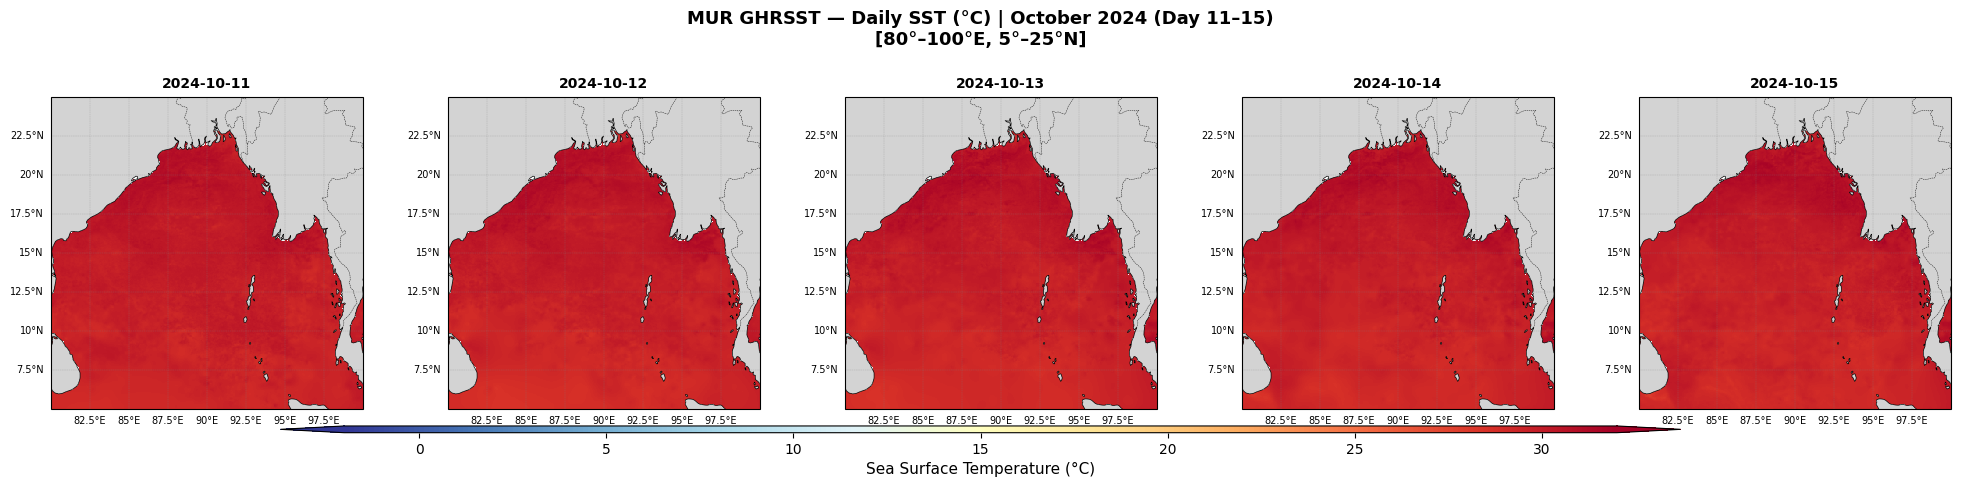

In [28]:
if DO_DAILY:
    daily_outputs = []
    for yr in YEARS:
        path = create_daily_plots(
            all_files=all_files,
            year=yr,
            month=DAILY_MONTH,
            day_start=DAILY_DAY_START,
            day_end=DAILY_DAY_END,
            days_per_row=DAYS_PER_ROW,
            output_dir=OUTPUT_DIR,
            region=REGION,
            region_label=REGION_LABEL,
            vmin=SST_VMIN,
            vmax=SST_VMAX,
            cmap=SST_CMAP,
            downsample=DOWNSAMPLE,
        )
        if path:
            daily_outputs.append(path)
else:
    print("DO_DAILY = False — skipping daily plots.")
    daily_outputs = []

---
## Section 8 — Summary

In [20]:
print("=" * 65)
print("RUN COMPLETE — output files")
print("=" * 65)

all_outputs = monthly_outputs + daily_outputs

if all_outputs:
    for p in all_outputs:
        print(f"  {p}")
else:
    print("  (no output files — check DO_MONTHLY / DO_DAILY in Configuration)")

print(f"\n  Total .nc files in dataset : {len(all_files)}")
print(f"  Years processed            : {YEARS}")
print(f"  Region                     : {REGION_LABEL}")

RUN COMPLETE — output files
  C:\Users\abhik\Downloads\New_folder\sst_plotssss\SST_Monthly_Mean_2024.png
  C:\Users\abhik\Downloads\New_folder\sst_plotssss\SST_Daily_2024_10_Day11-15.png

  Total .nc files in dataset : 367
  Years processed            : [2024]
  Region                     : [80°–100°E, 5°–25°N]
